# Numerical test of Legendre transform properties

In [68]:
import torch
from torch import Tensor
from geodesic_toolbox.samplers import Hamiltonian, ImplicitRHMCSampler
from geodesic_toolbox.solvers import ExpMapFinsler, GEORCEFinsler
from geodesic_toolbox.cometric import DualRandersMetrics, RandersMetrics, IdentityCoMetric
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde


In [69]:
class OneForm_dtheta(torch.nn.Module):
    """ Implements the normalized 1-form d theta in cartesian coordinate system.
    """

    def __init__(self, eta : float):
        super().__init__()
        self.eta = eta
    
    def forward(self, z : Tensor) -> Tensor :
        """Returns the vector representation of the 1-form d theta at a given point. 
        The 1-form is then computed with a dot product : 
        omega_z(v) = <omega(z), p>_g

        Args:
            z (Tensor): (Batch of) points on the manifold of shape (N_batch, 2)

        Returns:
            Tensor: (Batch of) tangent vectors that represent the 1-form of shape (N_batch, 2)
        """
        norm2 = torch.sum(z**2, axis = 1)
        norm = torch.sqrt(norm2)
        covect = torch.zeros_like(z)
        covect[:, 0] = -z[:,1]/norm
        covect[:, 1] = z[:,0]/norm
        return self.eta * covect


eta = 0.6
cometric = IdentityCoMetric()
omega_form = OneForm_dtheta(eta)
randers_metric = RandersMetrics(cometric, omega_form)
randers_cometric = DualRandersMetrics(randers_metric)

In [70]:
def reversed_legendre(p: torch.Tensor, G_star: torch.Tensor, w_star: torch.Tensor, eps: float = 1e-12,) -> torch.Tensor:
    """
    Reverse Legendre transform for a dual Randers norm.

    Args:
        p:      (batch, d) covectors
        G_star: (d, d) dual metric matrix
        w_star: (d,) dual drift vector
        eps:    small positive number to avoid division by zero

    Returns:
        (batch, d) vectors v = d_p (1/2 F^*(p)^2)
    """
    quad = torch.einsum("...i,...ij,...j->...", p, G_star, p)
    norm_term = torch.sqrt(quad.clamp_min(eps))
    dot_term = torch.einsum("...i,...i->...", p, w_star)

    F_star = norm_term + dot_term
    Gp = torch.einsum("...ij,...j->...i", G_star, p)

    return F_star.unsqueeze(-1) * (Gp / norm_term.unsqueeze(-1) + w_star)
    
def legendre_randers(v: torch.Tensor, G: torch.Tensor, w: torch.Tensor, eps: float = 1e-12,) -> torch.Tensor:
    """
    Legendre transform for a dual Randers norm.

    Args:
        v:      (batch, d) covectors
        G: (d, d) dual metric matrix
        w: (d,) dual drift vector
        eps:    small positive number to avoid division by zero

    Returns:
        (batch, d) vectors p = d_v (1/2 F(v)^2)
    """
    quad = torch.einsum("...i,...ij,...j->...", v, G, v)
    norm_term = torch.sqrt(quad.clamp_min(eps))
    dot_term = torch.einsum("...i,...i->...", v, w)

    F = norm_term + dot_term
    Gv = torch.einsum("...ij,...j->...i", G, v)

    return F.unsqueeze(-1) * (Gv / norm_term.unsqueeze(-1) + w)

## Effect of Legendre transform on momentum distribution

We start by comparing the empirical distribution of $v = L^*(p)$ whenever $p \sim \pi(p|z)$. Intuitivelly, we would like to recover 
\begin{equation}
    \pi(v|z) = \frac{\sigma_{BH}(z)}{(2\pi)^{d/2}}\exp\left(-\frac{1}{2}F_z^2(v)\right)
\end{equation}
as it is the case in the Riemannian setting. However, analytically we compute the following distribution : 
\begin{equation}
    \pi(v|z) = \frac{\sigma_{BH}^*(z)\det(G(z))}{(2\pi)^{d/2}}\exp\left(-\frac{1}{2}F_z^2(v)\right)\left(1+\frac{w^Tv}{\sqrt{v^TG(z)v}}\right)^{d+1}
\end{equation}

In [71]:
omega = torch.tensor([0.1, 0.2])

G = torch.tensor([[0.1, 0.], 
              [0.0, 0.2]])
G_inv = torch.linalg.inv(G)
alpha = 1 - (omega.unsqueeze(0) @ G_inv @ omega.unsqueeze(1)).item()  # scalar
omega_star = -1 / alpha * (G_inv @ omega)
G_inv_omega = G_inv @ omega
G_star = (1 / alpha**2) * (alpha * G_inv + torch.outer(G_inv_omega, G_inv_omega))


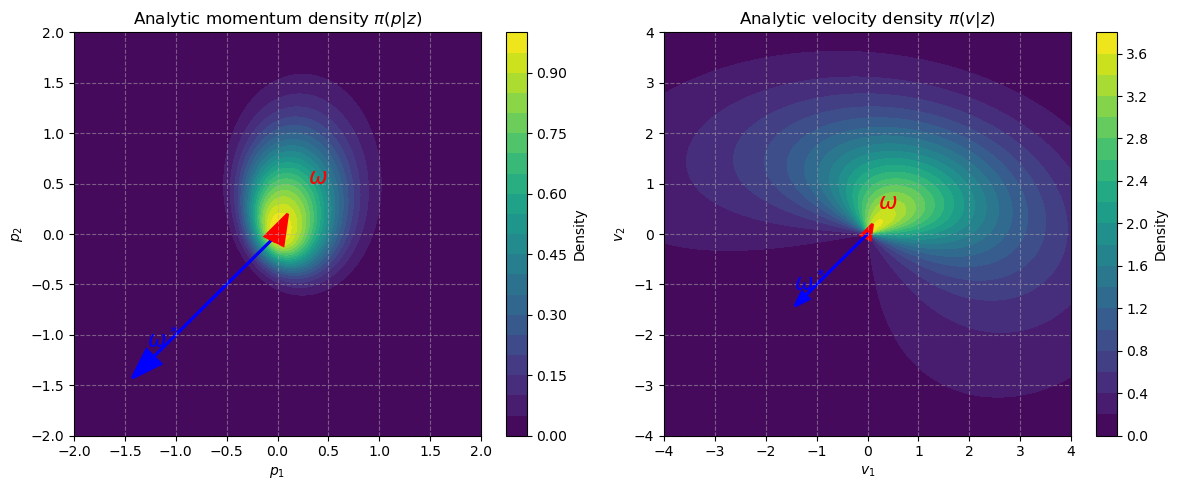

In [72]:
# Make a grid of (v1, v2) points for v_density (velocity, right plot)
v1 = np.linspace(-4, 4, 200)
v2 = np.linspace(-4, 4, 200)
V1, V2 = np.meshgrid(v1, v2)
VV = np.stack([V1, V2], axis=-1)  # shape (200, 200, 2)

# Make a grid of (p1, p2) points for p_density (momentum, left plot)
p1 = np.linspace(-2, 2, 200)  # zoom in for momentum density
p2 = np.linspace(-2, 2, 200)
P1, P2 = np.meshgrid(p1, p2)
PP = np.stack([P1, P2], axis=-1)

# Compute analytic v_density on the grid using omega and G already defined above (as numpy arrays)
def v_density_np(v, G, omega):
    d = G.shape[0]
    g_norm = np.sqrt(np.einsum("...i,ij,...j->...", v, G, v))
    v_dot_omega = np.einsum("...i,i->...", v, omega)
    # Avoid division by zero
    g_norm = np.where(g_norm == 0, 1e-10, g_norm)
    # Analytic velocity density per markdown cell
    return np.exp(-0.5 * (g_norm+v_dot_omega)**2) * (1 + v_dot_omega / g_norm)**(d+1)

# Compute analytic p_density on the grid using omega_star and G_star already defined above (as numpy arrays)
def p_density_np(p, G_star, omega_star):
    d = G_star.shape[0]
    g_norm = np.sqrt(np.einsum("...i,ij,...j->...", p, G_star, p))
    p_dot_omega = np.einsum("...i,i->...", p, omega_star)
    # Avoid division by zero
    g_norm = np.where(g_norm == 0, 1e-10, g_norm)
    # Analytic momentum density
    return np.exp(-0.5 * (g_norm + p_dot_omega)**2)

# Make sure G and omega are numpy arrays with correct shapes
G_np = G.numpy() if hasattr(G, 'numpy') else np.array(G)
omega_np = omega.numpy() if hasattr(omega, 'numpy') else np.array(omega)
if G_np.ndim == 3:
    G_np = G_np[0]
if omega_np.ndim > 1:
    omega_np = omega_np[0]

# Get corresponding star objects for p_density
G_star_np = G_star.numpy() if hasattr(G_star, 'numpy') else np.array(G_star)
omega_star_np = omega_star.numpy() if hasattr(omega_star, 'numpy') else np.array(omega_star)
if G_star_np.ndim == 3:
    G_star_np = G_star_np[0]
if omega_star_np.ndim > 1:
    omega_star_np = omega_star_np[0]

Z_v = v_density_np(VV, G_np, omega_np)
Z_p = p_density_np(PP, G_star_np, omega_star_np)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

def plot_arrow(ax, omega_vec, color, label):
    arrow_start = np.array([0.0, 0.0])
    ax.arrow(
        arrow_start[0],
        arrow_start[1],
        omega_vec[0],
        omega_vec[1],
        head_width=0.2,
        head_length=0.3,
        fc=color,
        ec=color,
        linewidth=2,
        length_includes_head=True
    )
    arrow_tip = arrow_start + omega_vec
    ax.annotate(
        label,
        xy=(arrow_tip[0], arrow_tip[1]),
        xytext=(arrow_tip[0] + 0.3, arrow_tip[1] + 0.3),
        color=color,
        fontsize=16,
        fontweight="bold",
        arrowprops=dict(arrowstyle="->", color=color, linewidth=0),
        ha='center'
    )

# Momentum subplot (left) -- show both omega and omega_star for clarity
contourf_p = axs[0].contourf(P1, P2, Z_p, levels=20, cmap='viridis')
axs[0].set_xlabel("$p_1$")
axs[0].set_ylabel("$p_2$")
axs[0].set_title(r"Analytic momentum density $\pi(p|z)$")
axs[0].grid(True, alpha=0.5, linestyle="--")
# Add omega_star and omega arrow to momentum plot
plot_arrow(axs[0], omega_star_np, "blue", r"$\omega^*$")
plot_arrow(axs[0], omega_np, "red", r"$\omega$")
fig.colorbar(contourf_p, ax=axs[0], label="Density")
axs[0].set_xlim([-2, 2])
axs[0].set_ylim([-2, 2])

# Velocity subplot (right plot) -- show both omega and omega_star for clarity
contourf_v = axs[1].contourf(V1, V2, Z_v, levels=20, cmap='viridis')
axs[1].set_xlabel("$v_1$")
axs[1].set_ylabel("$v_2$")
axs[1].set_title(r"Analytic velocity density $\pi(v|z)$")
axs[1].grid(True, alpha=0.5, linestyle="--")
# Add omega and omega_star arrows to velocity plot
plot_arrow(axs[1], omega_np, "red", r"$\omega$")
plot_arrow(axs[1], omega_star_np, "blue", r"$\omega^*$")
fig.colorbar(contourf_v, ax=axs[1], label="Density")
axs[1].set_xlim([-4, 4])
axs[1].set_ylim([-4, 4])

plt.tight_layout()
plt.show()

This distribution are also verified by sampling experimentally

In [6]:
def moebius_transform(u: Tensor, mu: Tensor, rho: Tensor, M: Tensor) -> Tensor:
    """
    Applies a Möbius transformation relevant to sampling on Riemannian manifolds.

    Args:
        u (Tensor): Input points of shape (batch_size, d).
        mu (Tensor): Mean direction vector of shape (d,).
        rho (Tensor): Scalar parameter controlling rotation/stretch (tensor scalar).
        M (Tensor): Symmetric positive definite matrix (covariance or metric) of shape (d, d).

    Returns:
        Tensor: Transformed points of shape (batch_size, d) after applying the Möbius transformation.
    """
    inner_prod = (u @ M @ mu).unsqueeze(-1) # (batch_size, 1)
    
    num = (1 - rho**2) * (u + rho * mu)
    den = 1 + 2 * rho * inner_prod + rho**2
    return (num / den) + rho * mu

def riemann_sphere_uniform_sampler(batch_size: int, d: int, L: Tensor) -> Tensor:
    """
    Uniformly samples points from the unit sphere with respect to the induced metric defined by L on ℝ^d.

    Args:
        batch_size (int): Number of points to sample.
        d (int): Dimension of the sphere (ambient space dimension).
        L (Tensor): Cholesky factor of a positive-definite matrix (d x d), typically representing the metric.

    Returns:
        Tensor: An array of shape (batch_size, d) containing batch_size points uniformly sampled on the
        L-induced unit sphere.
    """
    z = torch.randn(batch_size, d)
    z_unit = z / torch.linalg.norm(z, dim=-1, keepdim=True)
    
    # Solve L.T @ v = z_unit for the whole batch
    v = torch.linalg.solve_triangular(
        L.mT, 
        z_unit.mT, 
        upper=True
    ).mT
    
    return v


def momentum_exact_sampler(M: Tensor, w: Tensor, batch_size: int = 1, return_stats: bool = False):
    """
    Samples the initial momentum for the FHMC algorithm, exactly according to distribution induced by kinetic energy.

    Args:
        M (Tensor): The symmetric positive definite metric tensor of shape (d, d).
        w (Tensor): The potential vector of length d, defining the linear drift in momentum space.
        batch_size (int, optional): Number of independent momentum samples to generate. Defaults to 1.
        return_stats (bool, optional): If True, also returns the mean number of proposal iterations per sample. Defaults to False.

    Returns:
        Tensor: Sampled momentum tensor of shape (batch_size, d).
        float (optional): If return_stats is True, average number of iterations per sample is also returned.
    """
    d = M.shape[0]

    # Pre-computations
    M_inv = torch.linalg.inv(M)
    L = torch.linalg.cholesky(M)
    beta = torch.sqrt(w @ M_inv @ w)
    mu = -M_inv @ w / beta
    rho = beta / (1 + torch.sqrt(1 - beta**2))
    
    # Initialize containers for the accepted directions u'
    final_u_prime = torch.zeros((batch_size, d))
    accepted_mask = torch.zeros(batch_size, dtype=torch.bool)
    
    if return_stats: 
        iterations_per_sample = torch.zeros(batch_size)
    
    # Acceptance-Rejection for the direction u'
    while not accepted_mask.all():
        active_indices = torch.where(~accepted_mask)[0]
        num_to_sample = len(active_indices)
        
        if return_stats:   
            iterations_per_sample[active_indices] += 1
        
        # Sample u' candidates
        v_subset = riemann_sphere_uniform_sampler(num_to_sample, d, L)
        u_subset = moebius_transform(v_subset, mu, rho, M)
        
        # Bernoulli test 
        p = (1 - beta) / (1 + (u_subset @ w))
        alpha = torch.rand(num_to_sample) <= p
        
        if alpha.any():
            just_accepted_indices = active_indices[alpha]
            final_u_prime[just_accepted_indices] = u_subset[alpha]
            accepted_mask[just_accepted_indices] = True
            

    # Sample radius
    s = torch.randn(batch_size, d, device=M.device).norm(dim=-1)
    r = s / (1 + (final_u_prime @ w))
    
    # Final momentum q = r * u'
    final_q = r.unsqueeze(-1) * final_u_prime
    
    if return_stats:
        return final_q, iterations_per_sample.mean().item()
    
    return final_q

In [7]:
num_samples = 10**5
p, mean_iters = momentum_exact_sampler(G_star, omega_star, num_samples, return_stats=True)
v = reversed_legendre(p, G_star, omega_star)
print(f"Mean number of iterations: {mean_iters}")

Mean number of iterations: 1.5498900413513184


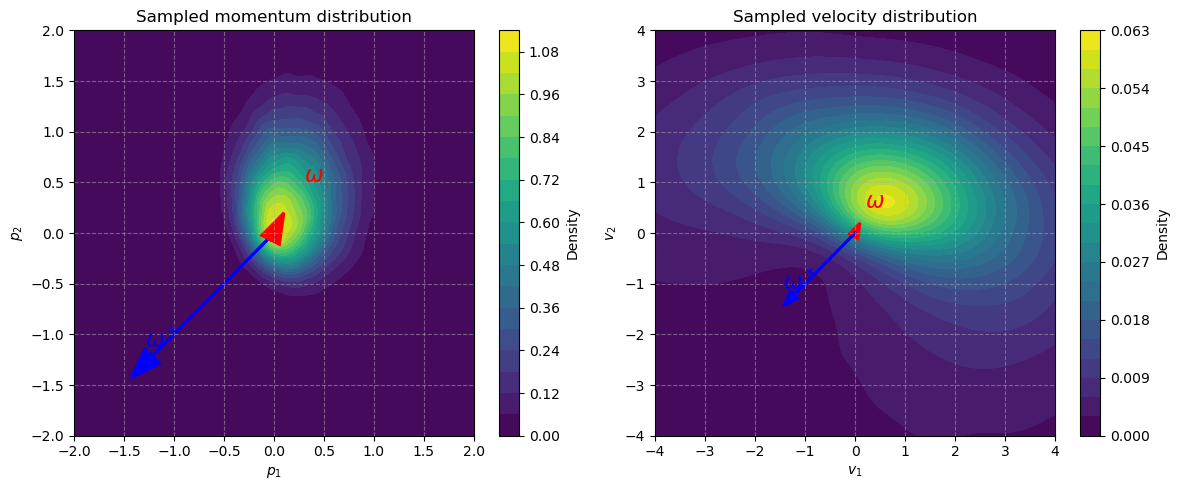

In [8]:
# Replicate the analytic plot style for the sampled momentum/velocity distributions

p_np = p.detach().cpu().numpy()
v_np = v.detach().cpu().numpy()

# For analytic style: set SAME grid as analytic (hardcoded boundaries)
p1 = np.linspace(-2, 2, 200)
p2 = np.linspace(-2, 2, 200)
P1, P2 = np.meshgrid(p1, p2)
PP = np.stack([P1, P2], axis=-1)
p_grid_flat = np.stack([P1.ravel(), P2.ravel()], axis=-1)

v1 = np.linspace(-4, 4, 200)
v2 = np.linspace(-4, 4, 200)
V1, V2 = np.meshgrid(v1, v2)
VV = np.stack([V1, V2], axis=-1)
v_grid_flat = np.stack([V1.ravel(), V2.ravel()], axis=-1)

# KDE on analytic grids (reshape to suit grid shape)
kde_p = gaussian_kde(p_np.T)
zz_p = kde_p(p_grid_flat.T).reshape(P1.shape)

kde_v = gaussian_kde(v_np.T)
zz_v = kde_v(v_grid_flat.T).reshape(V1.shape)

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Prepare both omega and omega_star as numpy arrays
omega_np = omega.detach().cpu().numpy() if hasattr(omega, "detach") else np.asarray(omega)
omega_star_np = omega_star.detach().cpu().numpy() if hasattr(omega_star, "detach") else np.asarray(omega_star)

def plot_arrow(ax, omega_vec, color, label):
    arrow_start = np.array([0.0, 0.0])
    ax.arrow(
        arrow_start[0],
        arrow_start[1],
        omega_vec[0],
        omega_vec[1],
        head_width=0.2,
        head_length=0.3,
        fc=color,
        ec=color,
        linewidth=2,
        length_includes_head=True
    )
    arrow_tip = arrow_start + omega_vec
    ax.annotate(
        label,
        xy=(arrow_tip[0], arrow_tip[1]),
        xytext=(arrow_tip[0] + 0.3, arrow_tip[1] + 0.3),
        color=color,
        fontsize=16,
        fontweight="bold",
        arrowprops=dict(arrowstyle="->", color=color, linewidth=0),
        ha='center'
    )

# Momentum plot (left)
contourf_p = axs[0].contourf(P1, P2, zz_p, levels=20, cmap='viridis')
axs[0].set_xlabel("$p_1$")
axs[0].set_ylabel("$p_2$")
axs[0].set_title(r"Sampled momentum distribution")
axs[0].grid(True, alpha=0.5, linestyle="--")

# Arrows with uniform style, different color for omega/omega_star
plot_arrow(axs[0], omega_star_np, "blue", r"$\omega^*$")
plot_arrow(axs[0], omega_np, "red", r"$\omega$")

fig.colorbar(contourf_p, ax=axs[0], label="Density")
axs[0].set_xlim([-2, 2])
axs[0].set_ylim([-2, 2])

# Velocity plot (right)
contourf_v = axs[1].contourf(V1, V2, zz_v, levels=20, cmap='viridis')
axs[1].set_xlabel("$v_1$")
axs[1].set_ylabel("$v_2$")
axs[1].set_title(r"Sampled velocity distribution")
axs[1].grid(True, alpha=0.5, linestyle="--")

# Arrows with uniform style, different color for omega/omega_star
plot_arrow(axs[1], omega_np, "red", r"$\omega$")
plot_arrow(axs[1], omega_star_np, "blue", r"$\omega^*$")

fig.colorbar(contourf_v, ax=axs[1], label="Density")
axs[1].set_xlim([-4, 4])
axs[1].set_ylim([-4, 4])

plt.tight_layout()
plt.show()

## Property test 1

The first test consists in the verification of the properties
\begin{equation}
    L^*(L(v)) = v, \qquad L(L^*(p))=p
\end{equation}

In [9]:
z = torch.tensor([[0., 1.]])
G_star = randers_cometric.G_star(z)      
w_star = randers_cometric.omega_star(z)  

G = torch.eye(2).unsqueeze(0)            
w = omega_form(z)                        

num_test = 10000
p = torch.randn(num_test, 2)
v = reversed_legendre(p, G_star, w_star)
p_bis = legendre_randers(v, G, w)

errors = (p_bis - p).norm(dim=1)
print(f"Largest error over {num_test} tests:", errors.max().item())

Largest error over 10000 tests: 1.1980384897469776e-06


In [10]:
num_test = 10000
v = torch.randn(10000, 2)
p = legendre_randers(v, G, w)
v_bis = reversed_legendre(p, G_star, w_star)

errors = (v_bis - v).norm(dim=1)
print(f"Largest error over {num_test} tests:", errors.max().item())

Largest error over 10000 tests: 9.610960205463925e-07


## Property test 2

Here we test the propery
\begin{equation}
    F(L^*(p)) = F^*_z(p), \qquad F^*_z(L(v)) = F_z(v)
\end{equation}

In [11]:
z = torch.tensor([[0., 1.]])
G_star = randers_cometric.G_star(z)      
w_star = randers_cometric.omega_star(z)  
G = torch.eye(2).unsqueeze(0)            
w = omega_form(z)   

num_test = 10000
p = torch.randn(num_test, 2)
v = reversed_legendre(p, G_star, w_star)

F_v = randers_metric(z, v)        
F_star_p = randers_cometric(z, p) 

F_v = F_v.squeeze()
F_star_p = F_star_p.squeeze()

errors = torch.abs(F_v - F_star_p)
print(f"Largest error over {num_test} tests:", errors.max().item())

Largest error over 10000 tests: 1.9073486328125e-06


In [12]:
num_test = 10000
v = torch.randn(num_test, 2)
p = legendre_randers(v, G, w)

F_v = randers_metric(z, v)        
F_star_p = randers_cometric(z, p) 

F_v = F_v.squeeze()
F_star_p = F_star_p.squeeze()

errors = torch.abs(F_v - F_star_p)
print(f"Largest error over {num_test} tests:", errors.max().item())

Largest error over 10000 tests: 1.430511474609375e-06


## Shooting test

In [61]:
class RandersImplicit(ImplicitRHMCSampler):

    def __init__(
        self,
        randers_cometric : DualRandersMetrics, 
        l : int, 
        N_fx : int,
        gamma : float,  
        bounds : float = 1e3, 
        std_0 : float = 1.0, 
        beta_0 : float = 1.0, 
        pbar : bool = False, 
        skip_acceptance = False
    ):
        super().__init__(
            randers_cometric.base_cometric, 
            l,
            N_fx, 
            gamma,
            0, 
            std_0, 
            bounds, 
            beta_0, 
            pbar, 
            skip_acceptance
        )
        self.randers_cometric = randers_cometric
    
    def U(self, z: Tensor) -> Tensor : 
        """_summary_

        Args:
            z (Tensor): _description_

        Returns:
            Tensor: _description_
        """
        # TODO ADD BUSEMANN-HAUSDORFF TERM
        b = z.shape[0]
        return torch.zeros(b)
    
    def K(self, p: Tensor, z: Tensor) -> Tensor:
        """_summary_

        Args:
            p (Tensor): _description_
            z (Tensor): _description_

        Returns:
            Tensor: _description_
        """
        # TODO ADD BUSEMANN-HAUSDORFF TERM
        return 0.5*self.randers_cometric(z, p)**2
    
    def tempering(self, k) -> float:
        return 1.

    def forward(self, z_0: Tensor, p_0 : Tensor) -> Tensor:  
        traj_q_0, _, = self.leapfrog(z_0, p_0, return_traj=True)
        return traj_q_0
        



In [73]:
leapfrog = RandersImplicit(
    randers_cometric, 
    l = 100, 
    N_fx= 6,
    gamma = 0.001, 
    )
exp_map = ExpMapFinsler(randers_metric)
geoforce = GEORCEFinsler(randers_metric)

In [97]:
z = torch.Tensor([[0., 1.]])
G_star = randers_cometric.G_star(z)[0,...]
omega_star = randers_cometric.omega_star(z)[0,...]

num_samples = 1
p, mean_iters = momentum_exact_sampler(G_star, omega_star, num_samples, return_stats=True)
v = reversed_legendre(p, G_star, omega_star)


In [98]:
print("Computing Hamiltonian trajectory...")
traj_ham = leapfrog(z, p)
print("Computing Hamiltonian geodesic...")
geo_ham = geoforce.get_trajectories(z, traj_ham[:,-1,:])

print("Computing Exp map trajectory...")
traj_exp = exp_map(z, v)
print("Computing Exp map geodesic...")
geo_exp = geoforce.get_trajectories(z, traj_exp[:,-1,:])

Computing Hamiltonian trajectory...
Computing Hamiltonian geodesic...
Computing Exp map trajectory...
Computing Exp map geodesic...


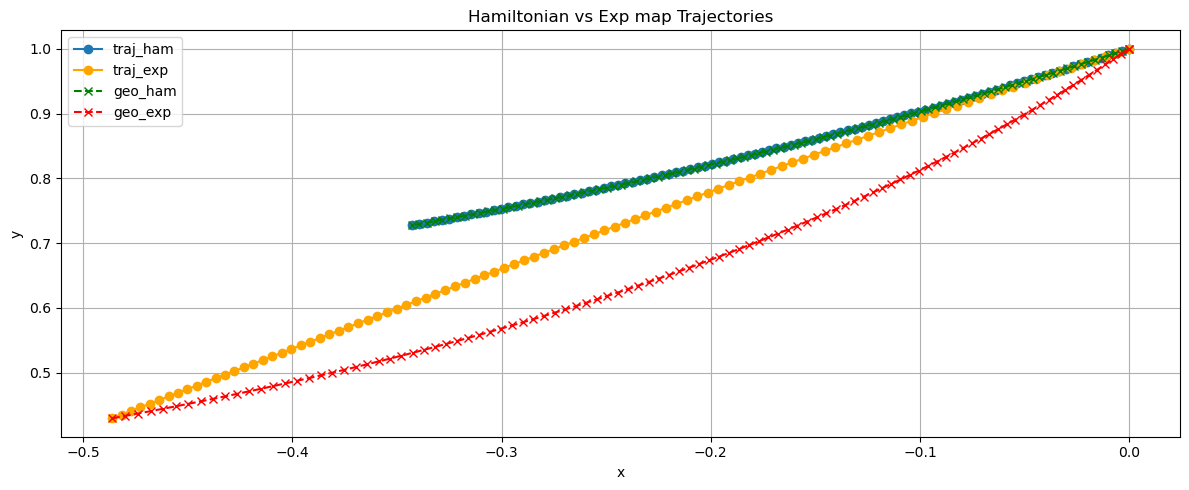

In [99]:
plt.figure(figsize=(12, 5))

plt.plot(traj_ham[0, :, 0].detach().numpy(), traj_ham[0, :, 1].detach().numpy(), marker='o', label='traj_ham')
plt.plot(traj_exp[0][:, 0].detach().numpy(), traj_exp[0][:, 1].detach().numpy(), marker='o', c='orange', label='traj_exp')

# Fix possible "too many indices" error for geo_ham and geo_exp
# If geo_ham or geo_exp are 2D (shape [n, d]), index as [:,0], [:,1]
if geo_ham.ndim == 3:
    plt.plot(
        geo_ham[0, :, 0].detach().numpy(),
        geo_ham[0, :, 1].detach().numpy(),
        marker='x', linestyle='--', c='g', label='geo_ham'
    )
else:
    plt.plot(
        geo_ham[:, 0].detach().numpy(),
        geo_ham[:, 1].detach().numpy(),
        marker='x', linestyle='--', c='g', label='geo_ham'
    )

if geo_exp.ndim == 3:
    plt.plot(
        geo_exp[0, :, 0].detach().numpy(),
        geo_exp[0, :, 1].detach().numpy(),
        marker='x', linestyle='--', c='r', label='geo_exp'
    )
else:
    plt.plot(
        geo_exp[:, 0].detach().numpy(),
        geo_exp[:, 1].detach().numpy(),
        marker='x', linestyle='--', c='r', label='geo_exp'
    )

plt.title('Hamiltonian vs Exp map Trajectories')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()